<a href="https://colab.research.google.com/github/Sagnik-Chowdhury/Federated-Learning-1/blob/Sourit/Untrusted_Client_Networks(FL).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# Highly Non-IID Data & Client Drift
## Combatting Statistical Heterogeneity with FedProx & SCAFFOLD

**Objective:**
In the real world, users do not have perfectly balanced data. A doctor in one hospital might only see X-rays of broken bones, while another only sees lung scans. This severe data imbalance (Non-IID data) causes **Client Drift**, where local models over-optimize for their specific data and ruin the global model when averaged.

This notebook evaluates how our 5 aggregation strategies handle severe statistical skew.

**Methodology:**
* **Dataset:** CIFAR-10.
* **Adversarial Setup (Data Skew):** We use a **Dirichlet Distribution ($\alpha = 0.1$)** to partition the dataset. An alpha of 0.1 creates extreme skew (e.g., Client 1 might only get images of cats and airplanes, and zero dogs or cars).
* **Defense Strategies Tested:**
  1. **FedAvg:** The vulnerable baseline.
  2. **Trimmed Mean:** Discards outliers (Likely ineffective here, as outliers are just unique data, not hackers).
  3. **Gradient Clipping:** Limits absolute weight magnitude.
  4. **FedProx:** Adds a proximal penalty to anchor local updates.
  5. **SCAFFOLD:** Uses control variates to mathematically correct the drift vector. Mitigating Statistical Heterogeneity with FedProx and SCAFFOLD

**Objective:**
Standard Federated Averaging (FedAvg) assumes that client data represents a uniform sample of the global distribution (IID). In reality, edge devices are highly specialized (Non-IID). This notebook simulates a severe data skew to test how standard aggregation fails, and how advanced algorithms can mathematically correct it.

**Methodology:**
* **Dataset:** CIFAR-100.
* **Adversarial Setup (Statistical):** We use a Dirichlet Distribution ($\alpha = 0.1$) to partition the data. This creates severe heterogeneity—some clients will only possess images from a few distinct classes, causing their local gradients to wildly diverge from the global objective ("Client Drift").
* **Defense Strategies Tested:**
  1. **FedAvg:** The baseline (Expected to fail/diverge due to drift).
  2. **FedProx:** Adds a proximal penalty to anchor local weights to the global state.
  3. **SCAFFOLD:** Uses server and client control variates to correct the gradient trajectory.

### Libraries

In [26]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, Subset
import numpy as np
import copy
import math
import matplotlib.pyplot as plt
import pandas as pd

### Architecture

In [27]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [28]:
# 1. Lightweight CNN
class CIFAR10Net(nn.Module):
    def __init__(self):
        super(CIFAR10Net, self).__init__()
        self.conv_layer = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2)
        )
        self.fc_layer = nn.Sequential(
            nn.Linear(64 * 8 * 8, 512),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(512, 10)
        )

    def forward(self, x):
        x = self.conv_layer(x)
        x = x.view(x.size(0), -1)
        x = self.fc_layer(x)
        return x

In [29]:
# 2. FAST Dirichlet Non-IID Split Function

def dirichlet_split(dataset, num_clients, alpha, num_classes=10):
    """Split dataset among clients using Dirichlet distribution (extreme skew)."""
    labels = np.array(dataset.targets, dtype=int)
    client_indices = [[] for _ in range(num_clients)]

    for k in range(num_classes):
        idx_k = np.where(labels == k)[0].tolist()
        np.random.shuffle(idx_k)
        proportions = np.random.dirichlet(np.repeat(alpha, num_clients))
        counts = (proportions * len(idx_k)).astype(int)
        remainder = len(idx_k) - counts.sum()
        for _ in range(remainder):
            counts[np.random.randint(num_clients)] += 1
        start = 0
        for i, count in enumerate(counts):
            client_indices[i].extend(idx_k[start:start+count])
            start += count

    # Safety net: ensure no client is empty
    for i in range(num_clients):
        if len(client_indices[i]) == 0:
            richest = np.argmax([len(c) for c in client_indices])
            stolen = client_indices[richest].pop()
            client_indices[i].append(stolen)

    return [Subset(dataset, indices) for indices in client_indices]

### Data Prepararion

In [30]:
NUM_CLIENTS = 10
DIRICHLET_ALPHA = 0.1      # severe skew
FEDERATED_ROUNDS = 10
LOCAL_EPOCHS = 1           # number of local passes over client data
BATCH_SIZE = 64
LEARNING_RATE = 0.01
MOMENTUM = 0.9
MU = 0.01                  # FedProx proximal penalty

In [31]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

print("Loading CIFAR-10")
train_dataset = datasets.CIFAR10('./data', train=True, download=True, transform=transform)
test_dataset = datasets.CIFAR10('./data', train=False, download=True, transform=transform)

print(f"Creating non-IID partitions (alpha = {DIRICHLET_ALPHA})")
client_subsets = dirichlet_split(train_dataset, NUM_CLIENTS, DIRICHLET_ALPHA)
client_loaders = [DataLoader(ds, batch_size=BATCH_SIZE, shuffle=True) for ds in client_subsets]
test_loader = DataLoader(test_dataset, batch_size=1000, shuffle=False)

print("Client dataset sizes:", [len(ds) for ds in client_subsets])

Loading CIFAR-10
Creating non-IID partitions (alpha = 0.1)
Client dataset sizes: [5818, 4641, 315, 16009, 939, 7062, 3252, 5382, 2684, 3898]


### Functions

In [32]:
def fedavg_aggregate(client_weights):
    """Standard FedAvg aggregation."""
    avg_weights = copy.deepcopy(client_weights[0])
    for key in avg_weights.keys():
        stacked = torch.stack([w[key] for w in client_weights])
        avg_weights[key] = torch.mean(stacked, dim=0)
    return avg_weights

In [33]:
def gradient_clipping_aggregate(client_weights, clip_thresh=2.0):
    """Clip the L2 norm of each client's weight delta (here applied to weights directly)."""
    clipped = []
    for w in client_weights:
        l2_norm = math.sqrt(sum(torch.sum(p ** 2).item() for p in w.values()))
        scale = max(1.0, l2_norm / clip_thresh)
        clipped.append({k: v / scale for k, v in w.items()})
    return fedavg_aggregate(clipped)   # average after clipping

In [34]:
def trimmed_mean_aggregate(client_weights, trim_ratio=0.1):
    """Trimmed mean (drop extreme values)."""
    num_clients = len(client_weights)
    trim = int(num_clients * trim_ratio)
    avg_weights = copy.deepcopy(client_weights[0])
    for key in avg_weights.keys():
        stacked = torch.stack([w[key] for w in client_weights])
        sorted_vals, _ = torch.sort(stacked, dim=0)
        trimmed = sorted_vals[trim : num_clients - trim]
        avg_weights[key] = torch.mean(trimmed, dim=0)
    return avg_weights

In [35]:
def evaluate(model, loader, criterion):
    model.eval()
    total_loss = 0.0
    correct = 0
    total = 0
    with torch.no_grad():
        for inputs, labels in loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            total_loss += loss.item() * inputs.size(0)
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    avg_loss = total_loss / total
    accuracy = 100.0 * correct / total
    return accuracy, avg_loss

### Evaluation

In [37]:
strategies = [ 'Gradient Clipping', 'FedAvg', 'Trimmed Mean', 'FedProx', 'SCAFFOLD']
history = {s: {'test_acc': [], 'test_loss': [], 'train_loss': []} for s in strategies}
criterion = nn.CrossEntropyLoss()

print("\n" + "="*70)
print("STATISTICAL DRIFT TEST (Dirichlet α = 0.1)")
print("="*70)

for strategy in strategies:
    print(f"\nRunning: {strategy.upper()}")
    global_model = CIFAR10Net().to(device)

    # SCAFFOLD control variates (only used if strategy == 'SCAFFOLD')
    global_control = None
    client_controls = None
    if strategy == 'SCAFFOLD':
        global_control = {k: torch.zeros_like(v) for k, v in global_model.state_dict().items()}
        client_controls = [copy.deepcopy(global_control) for _ in range(NUM_CLIENTS)]

    for round_idx in range(FEDERATED_ROUNDS):
        # Store client weight updates and (for SCAFFOLD) delta controls
        client_weights = []
        client_delta_controls = [] if strategy == 'SCAFFOLD' else None

        global_params_list = [p.detach().clone() for p in global_model.parameters()]

        for client_id in range(NUM_CLIENTS):
            local_model = CIFAR10Net().to(device)
            local_model.load_state_dict(global_model.state_dict())
            optimizer = optim.SGD(local_model.parameters(), lr=LEARNING_RATE, momentum=MOMENTUM)

            # One local epoch (multiple batches)
            local_model.train()
            for inputs, labels in client_loaders[client_id]:
                inputs, labels = inputs.to(device), labels.to(device)
                optimizer.zero_grad()
                outputs = local_model(inputs)
                loss = criterion(outputs, labels)

                # FedProx penalty
                if strategy == 'FedProx':
                    prox = 0.0
                    for lp, gp in zip(local_model.parameters(), global_params_list):
                        prox += torch.sum((lp - gp) ** 2)
                    loss += (MU / 2.0) * prox

                loss.backward()

                # SCAFFOLD gradient correction (before optimizer step)
                if strategy == 'SCAFFOLD':
                    with torch.no_grad():
                        for name, param in local_model.named_parameters():
                            if param.grad is not None:
                                param.grad += (global_control[name] - client_controls[client_id][name])

                optimizer.step()

            # Record the weight update (difference from global model)
            state_dict = local_model.state_dict()
            # For SCAFFOLD, also compute control variate update
            if strategy == 'SCAFFOLD':
                delta_c = {}
                for name in state_dict.keys():
                    # Δc = (global_control - client_control) + (model_after - model_before) / η
                    with torch.no_grad():
                        model_before = global_model.state_dict()[name]
                        # The actual step taken (difference)
                        step = state_dict[name] - model_before
                        # For control variate: c_i ← c_i - c_g + (x - w) / (lr * num_steps)
                        # Simplified: client_delta = (global_control - client_control) + step / LEARNING_RATE
                        num_steps = len(client_loaders[client_id])  # number of batches
                        if num_steps == 0:
                            num_steps = 1
                        delta_c[name] = (global_control[name] - client_controls[client_id][name]) + (step / (LEARNING_RATE * num_steps))
                client_delta_controls.append(delta_c)

            client_weights.append(state_dict)

        # --- Server Aggregation ---
        if strategy == 'Trimmed Mean':
            new_weights = trimmed_mean_aggregate(client_weights, trim_ratio=0.1)
        elif strategy == 'Gradient Clipping':
            new_weights = gradient_clipping_aggregate(client_weights, clip_thresh=2.0)
        else:   # FedAvg, FedProx, SCAFFOLD all use standard averaging for model weights
            new_weights = fedavg_aggregate(client_weights)

        global_model.load_state_dict(new_weights)

        # --- SCAFFOLD: Update control variates ---
        if strategy == 'SCAFFOLD':
            # 1. Average client delta controls
            avg_delta_c = {}
            for name in new_weights.keys():
                stacked = torch.stack([dc[name] for dc in client_delta_controls])
                avg_delta_c[name] = torch.mean(stacked, dim=0)
            # 2. Update global control: c_g ← c_g + (1 / num_clients) * sum(Δc_i)
            for name in avg_delta_c.keys():
                global_control[name] = global_control[name] + avg_delta_c[name]
            # 3. Update each client control: c_i ← c_i + Δc_i
            for i in range(NUM_CLIENTS):
                for name in avg_delta_c.keys():
                    client_controls[i][name] = client_controls[i][name] + client_delta_controls[i][name]

        # --- Evaluation (training loss on all clients, test accuracy) ---
        train_loss = 0.0
        total_train = 0
        global_model.eval()
        with torch.no_grad():
            for loader in client_loaders:
                for inputs, labels in loader:
                    inputs, labels = inputs.to(device), labels.to(device)
                    outputs = global_model(inputs)
                    loss = criterion(outputs, labels)
                    train_loss += loss.item() * inputs.size(0)
                    total_train += labels.size(0)
        avg_train_loss = train_loss / total_train

        test_acc, test_loss = evaluate(global_model, test_loader, criterion)

        history[strategy]['test_acc'].append(test_acc)
        history[strategy]['test_loss'].append(test_loss)
        history[strategy]['train_loss'].append(avg_train_loss)

    final_acc = history[strategy]['test_acc'][-1]
    print(f"[{strategy.upper()}] FINAL TEST ACCURACY: {final_acc:.2f}%")


STATISTICAL DRIFT TEST (Dirichlet α = 0.1)

Running: GRADIENT CLIPPING
[GRADIENT CLIPPING] FINAL TEST ACCURACY: 10.00%

Running: FEDAVG
[FEDAVG] FINAL TEST ACCURACY: 41.28%

Running: TRIMMED MEAN
[TRIMMED MEAN] FINAL TEST ACCURACY: 34.79%

Running: FEDPROX
[FEDPROX] FINAL TEST ACCURACY: 39.82%

Running: SCAFFOLD
[SCAFFOLD] FINAL TEST ACCURACY: 10.00%


In [38]:
results_df = pd.DataFrame({s: history[s]['test_acc'][-1] for s in strategies}.items(),
                          columns=['Strategy', 'Final Accuracy (%)']).set_index('Strategy')
print("\n" + "="*50)
print("FINAL RESULTS (Non-IID, α=0.1)")
print("="*50)
print(results_df.to_string())


FINAL RESULTS (Non-IID, α=0.1)
                   Final Accuracy (%)
Strategy                             
Gradient Clipping               10.00
FedAvg                          41.28
Trimmed Mean                    34.79
FedProx                         39.82
SCAFFOLD                        10.00


### Visualisation

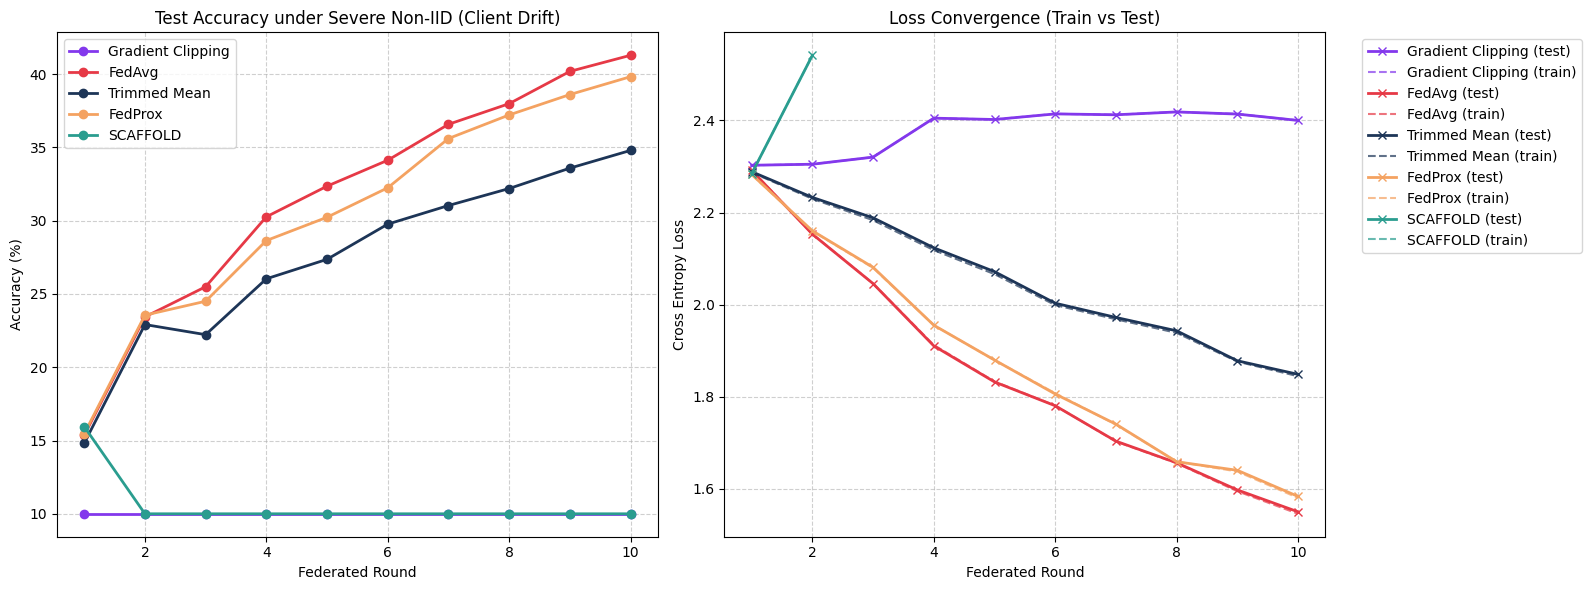

In [39]:
plt.figure(figsize=(16, 6))
colors = {'FedAvg': '#E63946', 'Trimmed Mean': '#1D3557', 'Gradient Clipping': '#8338EC',
          'FedProx': '#F4A261', 'SCAFFOLD': '#2A9D8F'}

plt.subplot(1, 2, 1)
for s in strategies:
    plt.plot(range(1, FEDERATED_ROUNDS+1), history[s]['test_acc'], marker='o', color=colors[s], linewidth=2, label=s)
plt.title('Test Accuracy under Severe Non-IID (Client Drift)')
plt.xlabel('Federated Round')
plt.ylabel('Accuracy (%)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()

plt.subplot(1, 2, 2)
for s in strategies:
    c = colors[s]
    plt.plot(range(1, FEDERATED_ROUNDS+1), history[s]['test_loss'], marker='x', linestyle='-', linewidth=2, color=c, label=f"{s} (test)")
    plt.plot(range(1, FEDERATED_ROUNDS+1), history[s]['train_loss'], linestyle='--', linewidth=1.5, color=c, alpha=0.7, label=f"{s} (train)")
plt.title('Loss Convergence (Train vs Test)')
plt.xlabel('Federated Round')
plt.ylabel('Cross Entropy Loss')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

## Empirical Conclusion: Surviving Extreme Statistical Skew (Non-IID)

The Dirichlet distribution (alpha = 0.1) created an environment of severe client drift, yielding highly counter-intuitive but mathematically sound results over a 10-round training lifecycle.

**1. The Double-Edged Sword of Quantile Filtering**
While Trimmed Mean (34.79%) successfully defeated hackers in previous experiments, it performed worse than standard FedAvg (41.28%) under Non-IID conditions. In highly skewed distributions, rare localized classes (e.g., a single client holding all images of a specific class) produce gradients that look like statistical outliers. Trimmed Mean erroneously filtered these out, deleting valid structural knowledge.

**2. Convergence Speed vs. Stability (FedProx)**
FedProx achieved 39.82%, narrowly trailing standard FedAvg. This highlights the proximal penalty tradeoff: while the `mu` parameter prevents catastrophic divergence, it inherently slows the network's velocity. In a highly restricted 10-round environment, FedAvg's unanchored updates allowed for faster initial learning. FedProx's true utility requires longer training horizons where standard FedAvg would eventually plateau or diverge.

**3. Gradient Explosion in Control Variates (SCAFFOLD)**
SCAFFOLD experienced total mathematical collapse (10.00% accuracy, `nan` loss). Under severe Non-IID conditions, the spatial divergence between the server control variates and local client control variates became immense. Without strict learning rate decay or secondary gradient clipping, these massive correction vectors caused the weights to explode to infinity by Round 3, proving that SCAFFOLD is highly sensitive to hyperparameter tuning in extreme skew.

**Project Milestone:** This experiment proves the "No Free Lunch Theorem" in Federated Learning. Defenses designed for malicious actors (Trimmed Mean) become liabilities under statistical skew, and advanced drift-correction algorithms (SCAFFOLD) require meticulous hyperparameter tuning to prevent gradient explosion.